In [20]:
import numpy as np
from matplotlib import pyplot as plt

In [21]:
def plt_hs(hs, min_fr=0.1, fig=None, ax=None, time_start=None, time_end=None):

    # time_points, num_neurons = hs.shape[0], hs.shape[1]

    # Select neurons with mean firing rate > 0.1
    mean_fr = hs.mean(axis=0)
    # Get the index where mean_fr > min_fr
    mask = mean_fr > min_fr
    neuron_indices = np.where(mask)[0]
    select_hs = hs[:, neuron_indices]
    del hs

    # Normalize the hs along time points (Sure to be correct!)
    # norm_hs = select_hs / np.linalg.norm(select_hs, axis=0, keepdims=True)
    # 0-1 Normalise method 2
    norm_hs = np.zeros_like(select_hs)
    for n in range(select_hs.shape[1]):
        norm_hs[:, n] = (select_hs[:, n]-np.min(select_hs[:, n]))/(np.max(select_hs[:, n])-np.min(select_hs[:, n]))
    del select_hs
    
    # Sort neurons from maximum firing time
    max_time = np.argmax(norm_hs, axis=0)
    sorted_neuron_indices = np.argsort(max_time)
    norm_hs = norm_hs[:, sorted_neuron_indices]
    
    time_pts, num_neurons = norm_hs.shape[0], norm_hs.shape[1]
    
    # Plot the normalized hs
    ax.imshow(norm_hs.T, aspect='auto', cmap='jet',  
              extent=[0, time_pts/10, num_neurons, 0]
              )
    
    # Plot a black dot at (max_time, neuron_index)
    if time_start is not None and time_end is not None:
        max_time_sorted = np.argmax(norm_hs, axis=0)
        # Plot those within the time interval
        time_mask = (max_time_sorted >= time_start) & (max_time_sorted <= time_end)
        y = np.arange(num_neurons)[time_mask]
        max_time_sorted = max_time_sorted[time_mask]
        ax.scatter(max_time_sorted/10, y, s=1, c='k')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Neurons')
    ax.set_xticks(np.linspace(0, norm_hs.shape[0]/10, 6))
    
    return norm_hs, fig, ax

(100, 512)
Num of time cells: 196
Interval length (s): 4.5


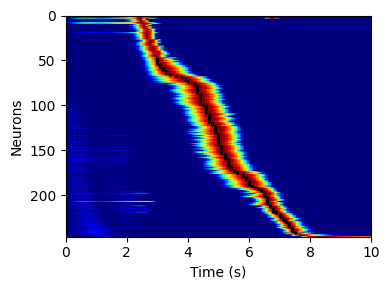

In [37]:
load_data_type = '2TS_vary0'
num_neuron = 512

data = np.load(f'../../data/{load_data_type}.npy', allow_pickle=True).item()
hidden_states = data[f'hidden_states_{num_neuron}']
avg_hs = np.mean(hidden_states, axis=0)
print(avg_hs.shape)

T = avg_hs.shape[0]
time_start, time_end = int(T * 0.3), int(T * 0.75)
# time_start, time_end = int(T * 0.3), int(T * 0.7)
# time_start, time_end = int(T * 0.35), int(T * 0.65)
# time_start, time_end = int(T * 0.4), int(T * 0.6)
# time_start, time_end = int(T * 0.45), int(T * 0.55)

# Plot the average hidden states
fig, ax = plt.subplots(figsize=(4, 3))
norm_hs, fig, ax = plt_hs(avg_hs, min_fr=0.1, fig=fig, ax=ax, time_start=time_start, time_end=time_end)
plt.tight_layout()
plt.xlabel('Time (s)')

# Get each neuron's max firing time
max_time_pts = np.argmax(norm_hs, axis=0)  

# Calculate the number of neurons with max firing time within the interval
num_in_interval = np.sum((max_time_pts >= time_start) & (max_time_pts <= time_end))
print('Num of time cells:', num_in_interval)
print('Interval length (s):', (time_end - time_start)/10)

In [34]:
num_time_cells = [196, 191, 171, 80, 45]
intervals = [4.5, 4.0, 3.0, 2.0, 0.6]

Correlation coefficient: 0.96


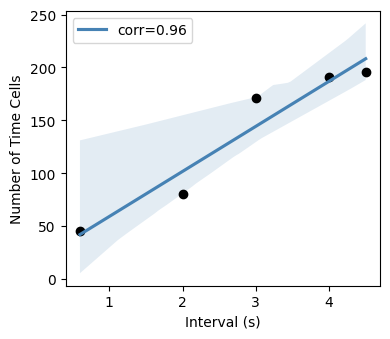

In [35]:
# Do a linear fit
def linear(x, m, b):
    return m * x + b
from scipy.optimize import curve_fit
popt, pcov = curve_fit(linear, intervals, num_time_cells)
x_fit = np.linspace(0, 5, 100)
y_fit = linear(x_fit, *popt)

# Calculate the correlation coefficient using seaborn
import seaborn as sns
fig, ax = plt.subplots(figsize=(4, 3.5))

correlation_matrix = np.corrcoef(intervals, num_time_cells)
correlation_coefficient = correlation_matrix[0, 1]
print(f'Correlation coefficient: {correlation_coefficient:.2f}')
sns.regplot(x=intervals, y=num_time_cells, ci=95, scatter=False, 
            line_kws={"color": 'steelblue', "label":f'corr={correlation_coefficient:.2f}'},
            label=r'corr={:.2f}'.format(correlation_coefficient))

# Plot num_time_cells vs intervals

# plt.plot(x_fit, y_fit, color='#297270')
ax.scatter(intervals, num_time_cells, marker='o', color='black')
ax.set_xlabel('Interval (s)')
ax.set_ylabel('Number of Time Cells')
plt.legend()
plt.tight_layout()

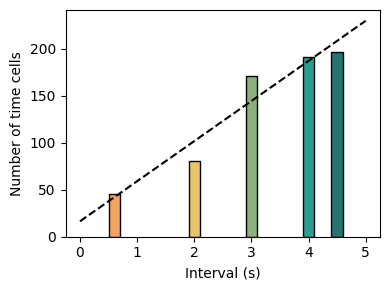

In [36]:
colours = ['#297270', '#299D8F', '#8AB07C',  '#E7C66B', '#F3A361']
fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(intervals, num_time_cells, color=colours, width=0.2, edgecolor='black')
# # Plot a linear fit in dashed line
ax.plot(x_fit, y_fit, color='black', linestyle='--', label='Linear fit')
ax.set_xlabel('Interval (s)')
ax.set_ylabel('Number of time cells')
plt.tight_layout()
plt.savefig('fig3_time_cell_corr_time_interval.png', transparent=True
            )